# Сравнение регрессоров на California Housing

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, OrthogonalMatchingPursuit
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.datasets import boston_housing

import optuna
import warnings
warnings.filterwarnings("ignore")

In [37]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Lasso": Lasso(alpha=0.1),
    "Orthogonal Matching Pursuit": OrthogonalMatchingPursuit(),
    "KNN Regressor": KNeighborsRegressor()
}

In [39]:
results = []
for name, model in models.items():
    print(f'Training: {name}')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

Training: Gradient Boosting
Training: Random Forest
Training: Lasso
Training: Orthogonal Matching Pursuit
Training: KNN Regressor


                         Model      RMSE       MAE  R2 Score
0            Gradient Boosting  3.597960  2.347420  0.844489
1                Random Forest  3.692649  2.434441  0.836196
2                        Lasso  4.718017  3.376196  0.732597
3                KNN Regressor  5.497983  3.502353  0.636876
4  Orthogonal Matching Pursuit  5.905607  4.117518  0.581036


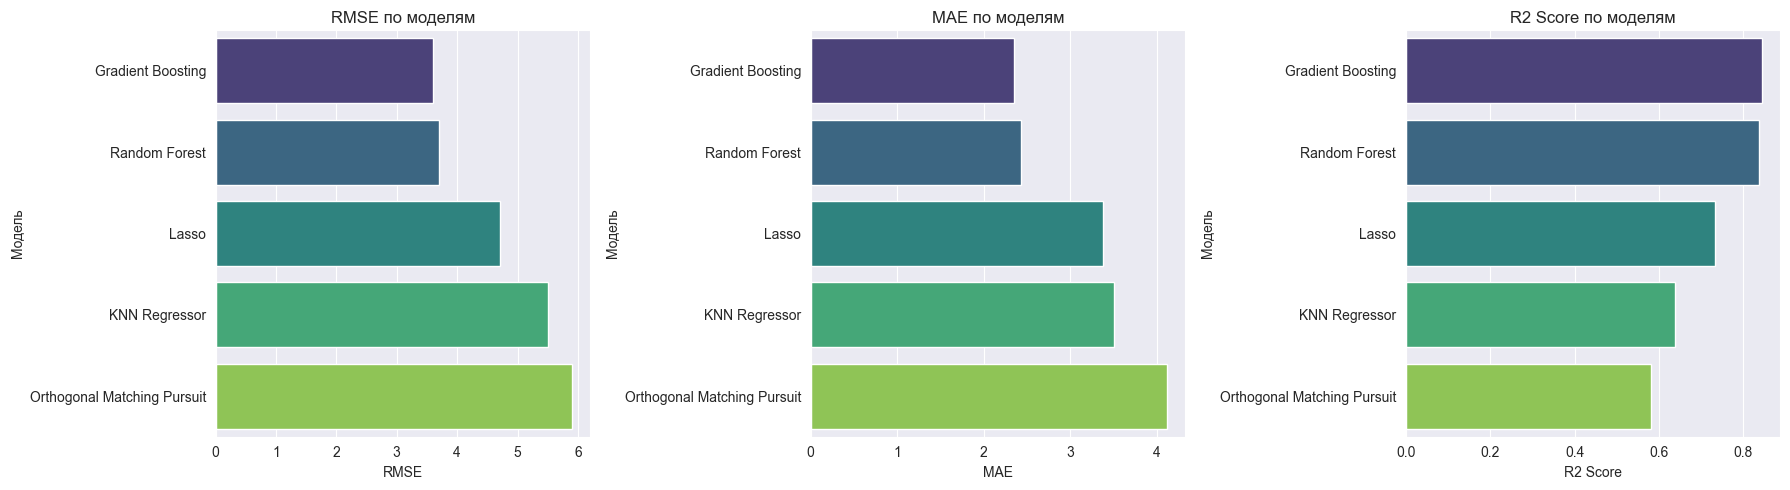

In [40]:
# Таблица результатов
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print(df_results_sorted)

# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'R2 Score']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=df_results_sorted, x=metric, y='Model', ax=ax, palette='viridis')
    ax.set_title(f'{metric} по моделям')
    ax.set_xlabel(metric)
    ax.set_ylabel('Модель')
plt.tight_layout()
plt.show()

In [55]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "random_state": 42
    }
    model = GradientBoostingRegressor(**params)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return r2_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Лучшие параметры:", study.best_params)
print("Лучшее R2:", study.best_value)

[I 2025-06-13 00:06:46,492] A new study created in memory with name: no-name-fb168d9a-d5b0-4ded-bbfb-7399a5397796
[I 2025-06-13 00:06:46,757] Trial 0 finished with value: 0.8408688673844085 and parameters: {'learning_rate': 0.05973404810635326, 'n_estimators': 111, 'max_depth': 5}. Best is trial 0 with value: 0.8408688673844085.
[I 2025-06-13 00:06:47,159] Trial 1 finished with value: 0.8432691352824183 and parameters: {'learning_rate': 0.025392096669721934, 'n_estimators': 280, 'max_depth': 2}. Best is trial 1 with value: 0.8432691352824183.
[I 2025-06-13 00:06:47,578] Trial 2 finished with value: 0.8343014624156708 and parameters: {'learning_rate': 0.18459080106554, 'n_estimators': 119, 'max_depth': 8}. Best is trial 1 with value: 0.8432691352824183.
[I 2025-06-13 00:06:48,302] Trial 3 finished with value: 0.7882279961390587 and parameters: {'learning_rate': 0.26749121300067064, 'n_estimators': 218, 'max_depth': 9}. Best is trial 1 with value: 0.8432691352824183.
[I 2025-06-13 00:06:

Лучшие параметры: {'learning_rate': 0.19923270585806233, 'n_estimators': 193, 'max_depth': 2}
Лучшее R2: 0.8867899447110776


Final RMSE: 3.0921444889287777
Final MAE: 2.159303277681365
Final R2 Score: 0.8851403712054665


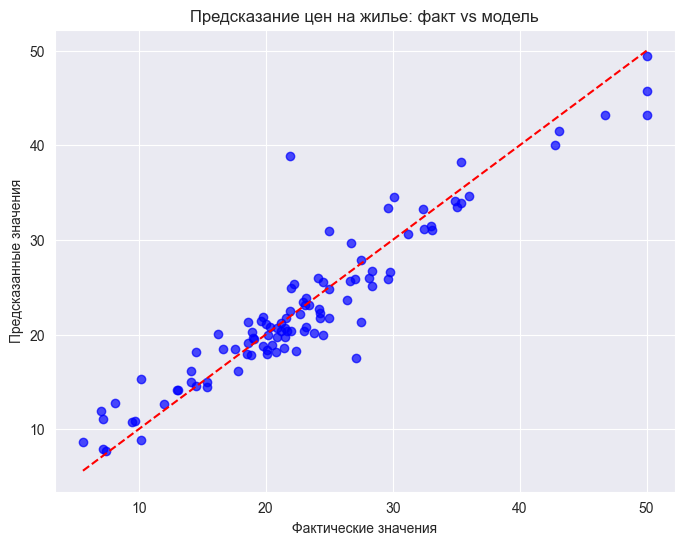

In [60]:
# Финальная модель с лучшими параметрами
final_model = GradientBoostingRegressor(**study.best_params)
final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("Final MAE:", mean_absolute_error(y_test, y_pred_final))
print("Final R2 Score:", r2_score(y_test, y_pred_final))

# Визуализация предсказания против факта
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Предсказание цен на жилье: факт vs модель")
plt.grid(True)
plt.show()
